In [11]:
import pandas as pd
import numpy as np

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor

from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

import matplotlib.pyplot as plt
import seaborn as sns
import shap

from sklearn.preprocessing import LabelEncoder


Load data

In [12]:
data_dir = r"D:\Personal\KAIM-10 Academy\Week 3\Project Work\Insurance Analytics_Predictive Modeling-Week 3\data\processed"

X_train = pd.read_csv(f"{data_dir}/X_train_regression.csv")
X_test = pd.read_csv(f"{data_dir}/X_test_regression.csv")
y_train = pd.read_csv(f"{data_dir}/y_train_regression.csv")
y_test = pd.read_csv(f"{data_dir}/y_test_regression.csv")

print("X_train shape:", X_train.shape)
print("y_train shape:", y_train.shape)
print("X_test shape:", X_test.shape)
print("y_test shape:", y_test.shape)

X_train shape: (487358, 211)
y_train shape: (700068, 1)
X_test shape: (300030, 211)
y_test shape: (300030, 1)


In [14]:
# Check columns
print(X_train.columns)
print(y_train.columns)

# If 'totalclaims' is in y_train but no PolicyID:
# Aggregate total claims per policy or per row index
# If no PolicyID, let's assume X_train and y_train rows correspond

# Align lengths by trimming y_train to match X_train
y_train_aligned = y_train.iloc[:X_train.shape[0]].copy()
y_test_aligned = y_test.iloc[:X_test.shape[0]].copy()

print("Aligned shapes:")
print("X_train:", X_train.shape, "y_train_aligned:", y_train_aligned.shape)
print("X_test:", X_test.shape, "y_test_aligned:", y_test_aligned.shape)

# Filter claims > 0
mask_train = y_train_aligned['totalclaims'] > 0
mask_test = y_test_aligned['totalclaims'] > 0

X_train_claims = X_train[mask_train].copy()
y_train_claims = y_train_aligned[mask_train].copy()

X_test_claims = X_test[mask_test].copy()
y_test_claims = y_test_aligned[mask_test].copy()

print("Filtered sizes:")
print("X_train_claims:", X_train_claims.shape, "y_train_claims:", y_train_claims.shape)
print("X_test_claims:", X_test_claims.shape, "y_test_claims:", y_test_claims.shape)


Index(['underwrittencoverid', 'policyid', 'isvatregistered', 'postalcode',
       'subcrestazone', 'mmcode', 'registrationyear', 'make', 'model',
       'cylinders',
       ...
       'covergroup_Standalone passenger liability',
       'covergroup_Third Party Only', 'covergroup_Trailer',
       'section_Motor Comprehensive', 'section_Optional Extended Covers',
       'section_Standalone passenger liability',
       'section_Third party or third party, fire and theft only',
       'product_Mobility Commercial Cover: Monthly',
       'product_Mobility Metered Taxis: Monthly',
       'product_Standalone Passenger Liability'],
      dtype='object', length=211)
Index(['totalclaims'], dtype='object')
Aligned shapes:
X_train: (487358, 211) y_train_aligned: (487358, 1)
X_test: (300030, 211) y_test_aligned: (300030, 1)
Filtered sizes:
X_train_claims: (1339, 211) y_train_claims: (1339, 1)
X_test_claims: (883, 211) y_test_claims: (883, 1)


In [16]:
non_numeric_cols = X_train_claims.select_dtypes(exclude=np.number).columns.tolist()

# Boolean-like columns
bool_cols = [col for col in non_numeric_cols if X_train_claims[col].dropna().isin([True, False]).all()]

# Remaining categorical columns
cat_cols = list(set(non_numeric_cols) - set(bool_cols))

# Convert boolean columns to int
for col in bool_cols:
    X_train_claims[col] = X_train_claims[col].astype(int)
    X_test_claims[col] = X_test_claims[col].astype(int)

# Encode categorical columns with LabelEncoder
from sklearn.preprocessing import LabelEncoder

for col in cat_cols:
    le = LabelEncoder()
    X_train_claims[col] = le.fit_transform(X_train_claims[col].astype(str))
    
    # Map unseen categories in test set to 'Unknown'
    X_test_claims[col] = X_test_claims[col].apply(lambda x: x if x in le.classes_ else "Unknown")
    le_classes = np.append(le.classes_, "Unknown")
    le.classes_ = le_classes
    X_test_claims[col] = le.transform(X_test_claims[col].astype(str))


train and evaluate Random Forest. We’ll do this step by step, start with Linear Regression.

In [22]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np

# Train Linear Regression
lr_model = LinearRegression()
lr_model.fit(X_train_claims, y_train_claims.values.ravel())

# Predict
y_pred_lr = lr_model.predict(X_test_claims)

# Evaluate
rmse_lr = np.sqrt(mean_squared_error(y_test_claims, y_pred_lr))
mae_lr = mean_absolute_error(y_test_claims, y_pred_lr)
r2_lr = r2_score(y_test_claims, y_pred_lr)

print(f"Linear Regression - RMSE: {rmse_lr:.2f}, MAE: {mae_lr:.2f}, R²: {r2_lr:.4f}")


Linear Regression - RMSE: 14.13, MAE: 6.74, R²: 0.1284


visualisation

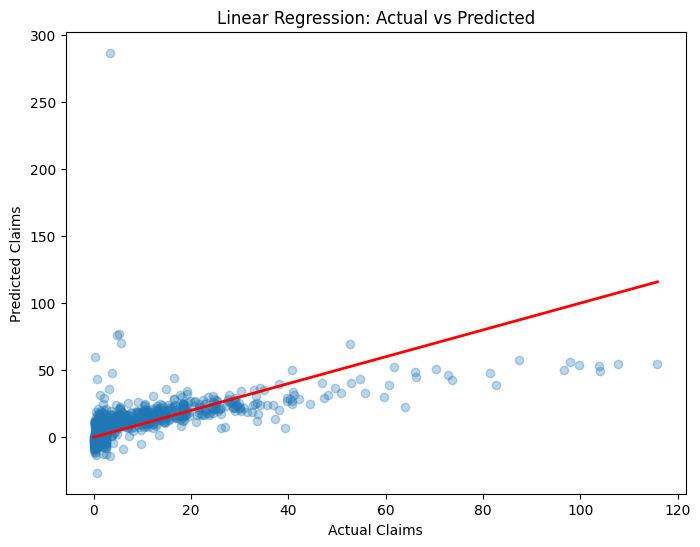

In [25]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))
plt.scatter(y_test_claims, y_pred_lr, alpha=0.3)
plt.plot([y_test_claims.min(), y_test_claims.max()],
         [y_test_claims.min(), y_test_claims.max()],
         color='red', linewidth=2)  # Perfect prediction line
plt.xlabel("Actual Claims")
plt.ylabel("Predicted Claims")
plt.title("Linear Regression: Actual vs Predicted")
plt.show()


Random Forest

In [23]:
from sklearn.ensemble import RandomForestRegressor

# Train Random Forest
rf_model = RandomForestRegressor(n_estimators=200, random_state=42, n_jobs=-1)
rf_model.fit(X_train_claims, y_train_claims.values.ravel())

# Predict
y_pred_rf = rf_model.predict(X_test_claims)

# Evaluate
rmse_rf = np.sqrt(mean_squared_error(y_test_claims, y_pred_rf))
mae_rf = mean_absolute_error(y_test_claims, y_pred_rf)
r2_rf = r2_score(y_test_claims, y_pred_rf)

print(f"Random Forest - RMSE: {rmse_rf:.2f}, MAE: {mae_rf:.2f}, R²: {r2_rf:.4f}")


Random Forest - RMSE: 3.24, MAE: 0.98, R²: 0.9541


Visualisation

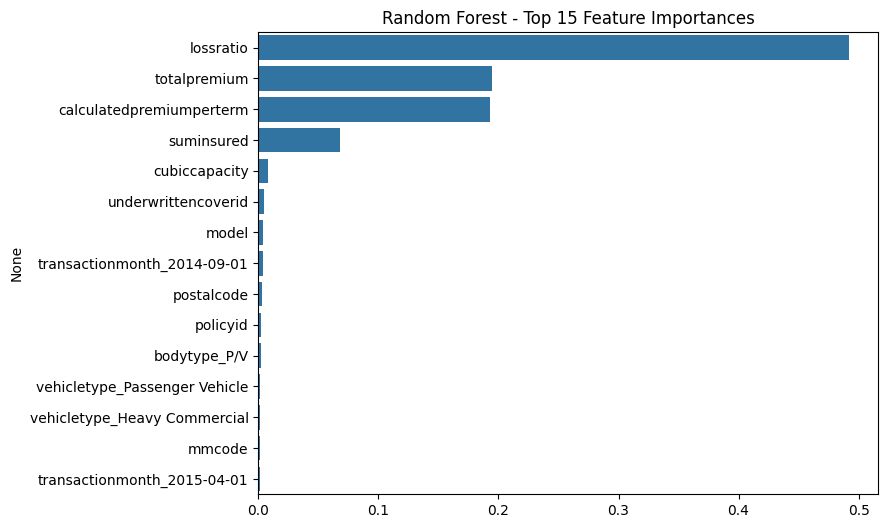

In [24]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

fi_rf = pd.Series(rf_model.feature_importances_, index=X_train_claims.columns).sort_values(ascending=False)[:15]
plt.figure(figsize=(8,6))
sns.barplot(x=fi_rf.values, y=fi_rf.index)
plt.title("Random Forest - Top 15 Feature Importances")
plt.show()


XGBoost (Gradient Boosting)

In [26]:
from xgboost import XGBRegressor

# Initialize XGBoost Regressor
xgb_model = XGBRegressor(
    n_estimators=200,       # number of trees
    learning_rate=0.1,      # step size shrinkage
    max_depth=5,            # maximum tree depth
    subsample=0.8,          # subsample ratio of training data
    colsample_bytree=0.8,   # subsample ratio of features
    random_state=42
)

print("XGBoost model initialized.")


XGBoost model initialized.


Train XGBoost on the claims data

In [27]:
# Train the XGBoost model
xgb_model.fit(X_train_claims, y_train_claims.values.ravel())

print("XGBoost model trained successfully.")

XGBoost model trained successfully.


In [28]:
# Predict on test set
y_pred_xgb = xgb_model.predict(X_test_claims)

# Evaluate
rmse_xgb = mean_squared_error(y_test_claims, y_pred_xgb)**0.5
mae_xgb = mean_absolute_error(y_test_claims, y_pred_xgb)
r2_xgb = r2_score(y_test_claims, y_pred_xgb)

print(f"XGBoost - RMSE: {rmse_xgb:.2f}, MAE: {mae_xgb:.2f}, R²: {r2_xgb:.4f}")


XGBoost - RMSE: 4.59, MAE: 1.42, R²: 0.9082


Feature Importance and SHAP for XGBoost

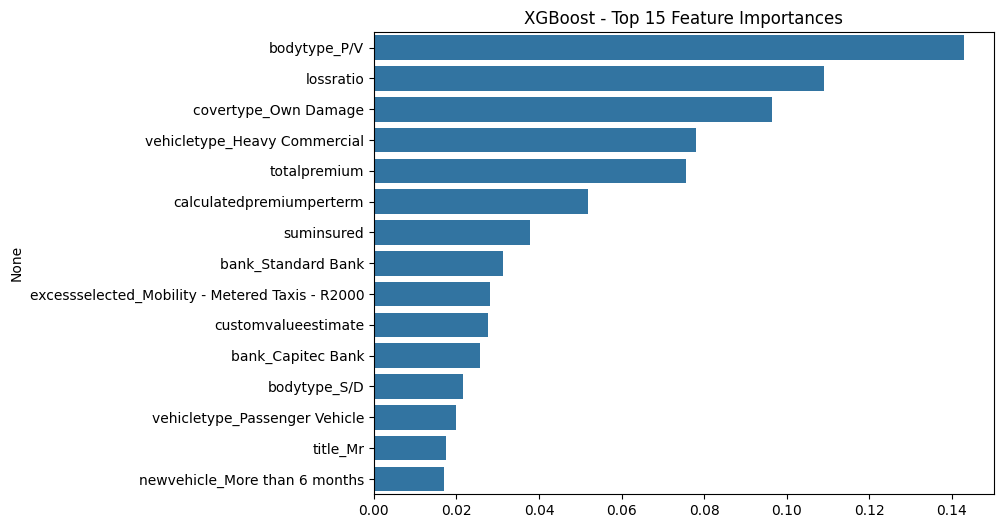

In [29]:
# -------------------------------
# Feature Importance (XGBoost)
# -------------------------------
fi_xgb = pd.Series(xgb_model.feature_importances_, index=X_train_claims.columns)
fi_xgb = fi_xgb.sort_values(ascending=False)[:15]

plt.figure(figsize=(8,6))
sns.barplot(x=fi_xgb.values, y=fi_xgb.index)
plt.title("XGBoost - Top 15 Feature Importances")
plt.show()


SHAP analysis for XGBoost to understand how each feature affects predictions.

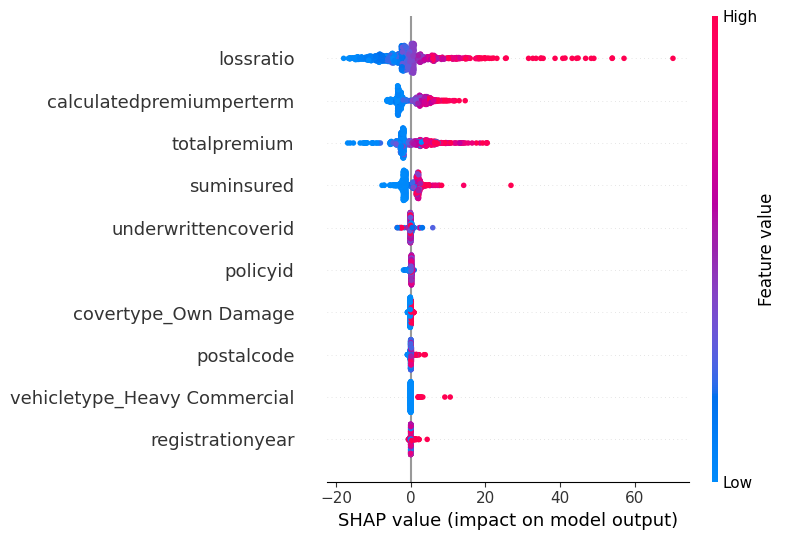


Top 10 Influential Features (SHAP) for XGBoost:


,Feature,Mean_Abs_SHAP
21,lossratio,5.819972
19,calculatedpremiumperterm,3.540302
20,totalpremium,3.462343
18,suminsured,2.015568
0,underwrittencoverid,0.199816
1,policyid,0.193110
182,covertype_Own Damage,0.145763
3,postalcode,0.119355
103,vehicletype_Heavy Commercial,0.110134
6,registrationyear,0.105132


In [30]:
# -------------------------------
# SHAP Analysis for XGBoost
# -------------------------------
import shap

# Initialize SHAP explainer
explainer_xgb = shap.Explainer(xgb_model, X_train_claims)

# Calculate SHAP values on test set
shap_values_xgb = explainer_xgb(X_test_claims)

# SHAP summary plot
shap.summary_plot(shap_values_xgb, X_test_claims, max_display=10)

# Create a DataFrame with top 10 influential features
shap_df_xgb = pd.DataFrame({
    'Feature': X_test_claims.columns,
    'Mean_Abs_SHAP': np.abs(shap_values_xgb.values).mean(axis=0)
}).sort_values(by='Mean_Abs_SHAP', ascending=False).head(10)

print("\nTop 10 Influential Features (SHAP) for XGBoost:")
display(shap_df_xgb)

Initialize and Train Decision Tree Regressor

In [31]:
from sklearn.tree import DecisionTreeRegressor

# Initialize
dt_model = DecisionTreeRegressor(max_depth=10, random_state=42)

# Train
dt_model.fit(X_train_claims, y_train_claims.values.ravel())


,criterion,'squared_error'
,splitter,'best'
,max_depth,10
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,ccp_alpha,0.0


Train the Decision tree

In [32]:
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# -------------------------------
# Train Decision Tree
# -------------------------------
dt_model = DecisionTreeRegressor(max_depth=10, random_state=42)
dt_model.fit(X_train_claims, y_train_claims.values.ravel())

# Predict on test set
y_pred_dt = dt_model.predict(X_test_claims)

# Evaluate
rmse_dt = mean_squared_error(y_test_claims, y_pred_dt) ** 0.5
mae_dt = mean_absolute_error(y_test_claims, y_pred_dt)
r2_dt = r2_score(y_test_claims, y_pred_dt)

print(f"Decision Tree - RMSE: {rmse_dt:.2f}, MAE: {mae_dt:.2f}, R²: {r2_dt:.4f}")


Decision Tree - RMSE: 4.09, MAE: 1.38, R²: 0.9270


Model Interpretation Using SHAP and LIME